# EDA figures for the data-construction chapter

Every figure is saved on its own as a vector PDF into `report/figures/`.
No subplots: composition happens in LaTeX.

Metadata for figure captions is printed under each plot, ready to copy.

In [2]:
from pathlib import Path
import csv, json, collections
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGS = REPO / "report/figures"; FIGS.mkdir(parents=True, exist_ok=True)
SPLIT = "sir0_train"          # sir0_val for the eval-side figures

# Journal style: serif, 9 pt, vector out, no chart junk.
mpl.rcParams.update({
    "font.family": "serif", "font.serif": ["Nimbus Roman", "DejaVu Serif"],
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 140, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.01,
    "pdf.fonttype": 42,
})
TEXTWIDTH_IN = 6.3      # A4 with 2.5 cm margins
INK = "#222222"; ACCENT = "#0B6E99"; ACCENT2 = "#C1440E"

def save(fig, name):
    p = FIGS / f"{name}.pdf"
    fig.savefig(p); print(f"saved {p.relative_to(REPO)}")

rows = list(csv.DictReader(open(REPO / f"data/manifests/{SPLIT}.csv")))
print(f"{len(rows)} trials in {SPLIT}")

9955 trials in sir0_train


## 1. Enrolment provenance

Where the enrolment clip came from, after the book → chapter → utterance fallback.
Bars are the fraction of trials at each level; the strictest is leftmost.

saved report/figures/enrollment_provenance.pdf


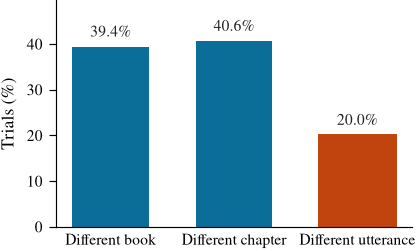


--- caption numbers ---
Different book          3918  (39.4%)
Different chapter       4042  (40.6%)
Different utterance     1995  (20.0%)
total 9955   split sir0_train


In [3]:
ORDER = ["book", "chapter", "utterance"]
LABEL = {"book": "Different book", "chapter": "Different chapter",
         "utterance": "Different utterance"}

counts = collections.Counter(r["enrollment_guard"] for r in rows)
n = sum(counts[k] for k in ORDER)
frac = [100 * counts[k] / n for k in ORDER]

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN * 0.52, 2.1))
bars = ax.bar([LABEL[k] for k in ORDER], frac,
              color=[ACCENT, ACCENT, ACCENT], width=0.62,
              edgecolor="none")
bars[2].set_color(ACCENT2)      # the weakest guard, called out
for b, f, k in zip(bars, frac, ORDER):
    ax.text(b.get_x() + b.get_width()/2, f + 1.2, f"{f:.1f}%",
            ha="center", va="bottom", fontsize=8, color=INK)
ax.set_ylabel("Trials (%)"); ax.set_ylim(0, max(frac) * 1.22)
ax.tick_params(axis="x", length=0)
save(fig, "enrollment_provenance"); plt.show()

print("\n--- caption numbers ---")
for k in ORDER:
    print(f"{LABEL[k]:22s} {counts[k]:5d}  ({100*counts[k]/n:.1f}%)")
print(f"total {n}   split {SPLIT}")

## 2. Two example rooms

Rebuilt from the manifest columns, which fully determine the acoustics.
Plan view; the room height and all other figures are printed for the caption.
Wall absorption is solved from $T_{60}$ by the Sabine relation, exactly as the
renderer does it.

saved report/figures/room_example_a.pdf


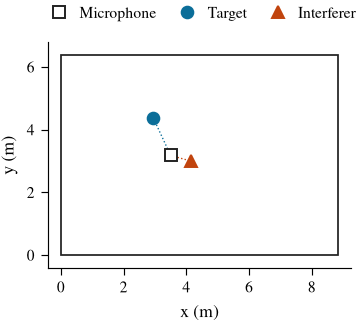


--- caption numbers for room_example_a ---
trial            sir0_train-42-007495  (regime base)
room             8.85 x 6.38 x 3.14 m   (177 m^3)
T60              0.250 s
wall absorption  0.5479   (Sabine, image-source order 30)
mic              (3.50, 3.18, 1.28) m
target           (2.94, 4.39, 1.66) m, 1.39 m from mic
interferer       (4.14, 3.00, 1.57) m, 0.72 m from mic
saved report/figures/room_example_b.pdf


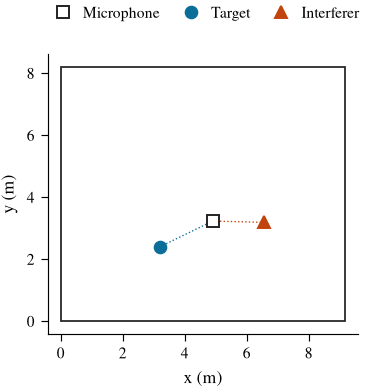


--- caption numbers for room_example_b ---
trial            sir0_train-42-004785  (regime hard)
room             9.18 x 8.21 x 3.48 m   (263 m^3)
T60              0.600 s
wall absorption  0.2594   (Sabine, image-source order 64)
mic              (4.91, 3.23, 1.49) m
target           (3.20, 2.40, 1.52) m, 1.90 m from mic
interferer       (6.56, 3.19, 1.64) m, 1.67 m from mic


In [4]:
import pyroomacoustics as pra

def room_facts(r):
    dims = [float(r["room_l"]), float(r["room_w"]), float(r["room_h"])]
    t60 = float(r["t60_s"])
    absorption, max_order = pra.inverse_sabine(t60, dims)
    mic = np.array([float(r["mic_x"]), float(r["mic_y"]), float(r["mic_z"])])
    tgt = np.array([float(r["target_x"]), float(r["target_y"]), float(r["target_z"])])
    itf = np.array([float(r["interferer_x"]), float(r["interferer_y"]), float(r["interferer_z"])])
    return dict(trial=r["trial_id"], dims=dims, t60=t60, absorption=absorption,
                max_order=max_order, mic=mic, target=tgt, interferer=itf,
                d_target=float(np.linalg.norm(tgt - mic)),
                d_interferer=float(np.linalg.norm(itf - mic)),
                volume=float(np.prod(dims)), regime=r["regime"])

def plot_room(f, name):
    l, w, h = f["dims"]
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN * 0.46, TEXTWIDTH_IN * 0.46 * w / l))
    ax.add_patch(plt.Rectangle((0, 0), l, w, fill=False, lw=0.9, ec=INK))
    for p, m, c, lab in [(f["mic"], "s", INK, "Microphone"),
                         (f["target"], "o", ACCENT, "Target"),
                         (f["interferer"], "^", ACCENT2, "Interferer")]:
        ax.plot(p[0], p[1], m, color=c, ms=6, label=lab,
                mfc=c if m != "s" else "white", mew=1.0)
    for p, c in [(f["target"], ACCENT), (f["interferer"], ACCENT2)]:
        ax.plot([f["mic"][0], p[0]], [f["mic"][1], p[1]],
                ls=":", lw=0.7, color=c, zorder=0)
    ax.set_xlim(-0.4, l + 0.4); ax.set_ylim(-0.4, w + 0.4)
    ax.set_aspect("equal"); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.22), ncol=3,
              handletextpad=0.3, columnspacing=1.0)
    save(fig, name); plt.show()

# pick two genuinely different rooms: driest/smallest against most reverberant/largest
both = [r for r in rows if r["condition"] == "both"]
by_t60 = sorted(both, key=lambda r: (float(r["t60_s"]), np.prod([float(r["room_l"]), float(r["room_w"])])))
examples = {"room_example_a": room_facts(by_t60[0]),
            "room_example_b": room_facts(by_t60[-1])}

for name, f in examples.items():
    plot_room(f, name)
    print(f"\n--- caption numbers for {name} ---")
    print(f"trial            {f['trial']}  (regime {f['regime']})")
    print(f"room             {f['dims'][0]:.2f} x {f['dims'][1]:.2f} x {f['dims'][2]:.2f} m"
          f"   ({f['volume']:.0f} m^3)")
    print(f"T60              {f['t60']:.3f} s")
    print(f"wall absorption  {f['absorption']:.4f}   (Sabine, image-source order {f['max_order']})")
    print(f"mic              ({f['mic'][0]:.2f}, {f['mic'][1]:.2f}, {f['mic'][2]:.2f}) m")
    print(f"target           ({f['target'][0]:.2f}, {f['target'][1]:.2f}, {f['target'][2]:.2f}) m,"
          f" {f['d_target']:.2f} m from mic")
    print(f"interferer       ({f['interferer'][0]:.2f}, {f['interferer'][1]:.2f}, {f['interferer'][2]:.2f}) m,"
          f" {f['d_interferer']:.2f} m from mic")

## 3. Two example trial timelines

Speech regions are taken with the same detector and the same settings that define
overlap in the pipeline, so the bars agree with the manifest's `overlap_achieved`.
The two examples are chosen to be distinct: one with little overlap, one heavily
overlapped.

saved report/figures/trial_timeline_low_overlap.pdf


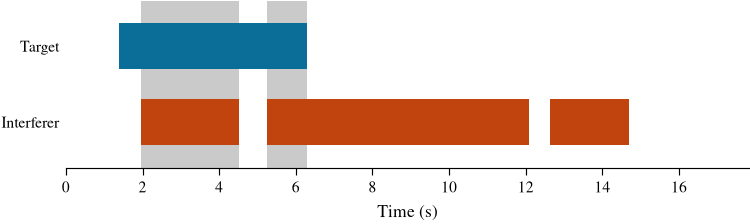


--- caption numbers for trial_timeline_low_overlap ---
trial              sir0_train-42-005949  (regime hard, condition both)
mixture length     17.42 s
overlap requested  0.200
overlap achieved   0.200
target activity    0.281
SIR / SNR          -0.79 dB / 1.11 dB
T60                0.415 s
same gender        yes   interrupted: yes
saved report/figures/trial_timeline_high_overlap.pdf


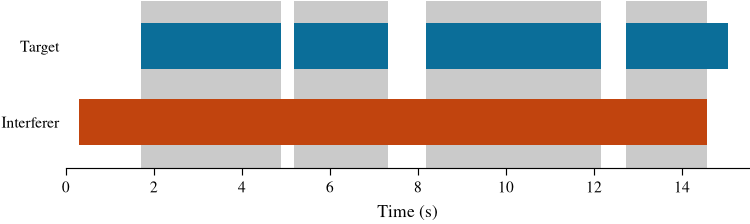


--- caption numbers for trial_timeline_high_overlap ---
trial              sir0_train-42-005390  (regime base, condition both)
mixture length     15.20 s
overlap requested  0.690
overlap achieved   0.719
target activity    0.764
SIR / SNR          9.37 dB / 17.61 dB
T60                0.329 s
same gender        no   interrupted: yes


In [8]:
import soundfile as sf, yaml, sys
sys.path.insert(0, str(REPO))
from src.data import vad

cfg = yaml.safe_load(open(REPO / "experiments/configs/generator.yaml"))
vcfg = vad.vad_config(cfg); vmodel = vad.load_model()

def speech_spans(wav_path):
    x, sr = sf.read(str(wav_path), dtype="float32")
    return vad.detect(x, vmodel, vcfg, sample_rate=sr), len(x) / sr

def plot_timeline(r, name):
    d = REPO / f"data/rendered/{SPLIT}/{r['trial_id']}"
    tgt, dur = speech_spans(d / "target.wav")
    itf, _   = speech_spans(d / "interferer.wav")
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 1.55))
    for segs, y, c, lab in [(tgt, 1, ACCENT, "Target"), (itf, 0, ACCENT2, "Interferer")]:
        for a, b in segs:                      # vad.detect returns (start_s, end_s)
            ax.add_patch(plt.Rectangle((a, y - 0.3), b - a, 0.6, color=c, ec="none"))
        ax.plot([], [], color=c, lw=5, label=lab)
    # shade where both talk
    for a1, b1 in tgt:
        for a2, b2 in itf:
            a, b = max(a1, a2), min(b1, b2)
            if b > a:
                ax.axvspan(a, b, color=INK, alpha=0.24, lw=0, zorder=0)
    ax.set_xlim(0, dur); ax.set_ylim(-0.6, 1.6)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Interferer", "Target"])
    ax.set_xlabel("Time (s)"); ax.tick_params(axis="y", length=0)
    ax.spines["left"].set_visible(False)
    save(fig, name); plt.show()

    print(f"\n--- caption numbers for {name} ---")
    print(f"trial              {r['trial_id']}  (regime {r['regime']}, condition {r['condition']})")
    print(f"mixture length     {float(r['mixture_length_s']):.2f} s")
    print(f"overlap requested  {float(r['overlap_requested']):.3f}")
    print(f"overlap achieved   {float(r['overlap_achieved']):.3f}")
    print(f"target activity    {float(r['target_activity']):.3f}")
    print(f"SIR / SNR          {r['sir_db']} dB / {r['snr_db']} dB")
    print(f"T60                {float(r['t60_s']):.3f} s")
    print(f"same gender        {'yes' if r['same_gender']=='1' else 'no'}"
          f"   interrupted: {'yes' if r['interrupted']=='1' else 'no'}")

overlapping = [r for r in both if float(r["overlap_achieved"]) > 0]
low  = min(overlapping, key=lambda r: abs(float(r["overlap_achieved"]) - 0.20))
high = max(overlapping, key=lambda r: float(r["overlap_achieved"]))
plot_timeline(low,  "trial_timeline_low_overlap")
plot_timeline(high, "trial_timeline_high_overlap")

## 4. Parameter distributions

One figure per parameter, so they can be placed independently in the appendix.
The point these make is that each parameter is *swept*, not fixed at a
convenient value.

saved report/figures/dist_overlap_achieved.pdf


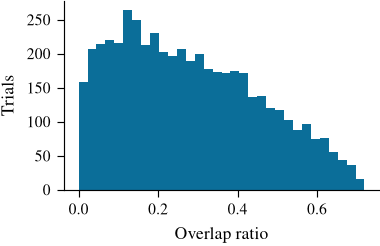

overlap_achieved: n=4930  min 0.000  p25 0.131  median 0.258  p75 0.410  max 0.719
saved report/figures/dist_sir_db.pdf


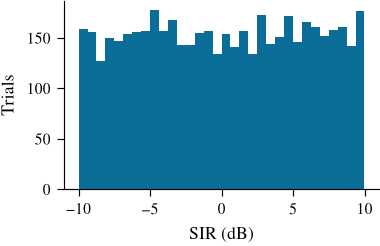

sir_db: n=4930  min -10.000  p25 -4.890  median 0.105  p75 5.140  max 9.990
saved report/figures/dist_snr_db.pdf


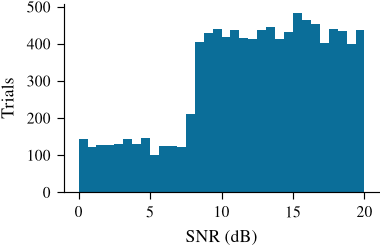

snr_db: n=9955  min 0.000  p25 9.255  median 12.910  p75 16.350  max 20.000


findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmti10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


saved report/figures/dist_t60_s.pdf


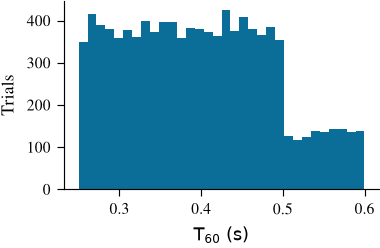

t60_s: n=9955  min 0.250  p25 0.322  median 0.393  p75 0.464  max 0.600
saved report/figures/dist_target_activity.pdf


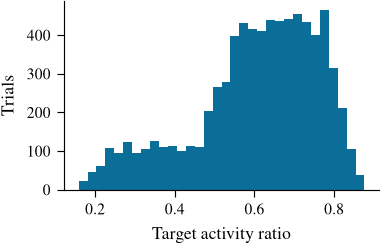

target_activity: n=7473  min 0.159  p25 0.522  median 0.629  p75 0.725  max 0.876
saved report/figures/dist_mixture_length_s.pdf


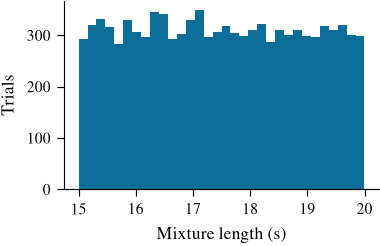

mixture_length_s: n=9955  min 15.000  p25 16.258  median 17.470  p75 18.730  max 19.999


In [6]:
# A parameter is only plotted over the trials where it is defined: overlap is
# meaningless unless both talk, activity unless the target talks.
BOTH_ONLY    = lambda r: r["condition"] == "both"
TARGET_TALKS = lambda r: r["target_absent"] == "0"
ALL          = lambda r: True

PARAMS = [
    ("overlap_achieved", "Overlap ratio",         BOTH_ONLY),
    ("sir_db",           "SIR (dB)",              BOTH_ONLY),
    ("snr_db",           "SNR (dB)",              ALL),
    ("t60_s",            "$T_{60}$ (s)",          ALL),
    ("target_activity",  "Target activity ratio", TARGET_TALKS),
    ("mixture_length_s", "Mixture length (s)",    ALL),
]

def plot_hist(key, xlabel, name, keep=ALL):
    vals = [float(r[key]) for r in rows if keep(r) and r[key] not in ("", None)]
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN * 0.46, 1.75))
    ax.hist(vals, bins=32, color=ACCENT, edgecolor="none")
    ax.set_xlabel(xlabel); ax.set_ylabel("Trials")
    save(fig, name); plt.show()
    q = np.percentile(vals, [0, 25, 50, 75, 100])
    print(f"{key}: n={len(vals)}  min {q[0]:.3f}  p25 {q[1]:.3f}  "
          f"median {q[2]:.3f}  p75 {q[3]:.3f}  max {q[4]:.3f}")

for key, xlabel, keep in PARAMS:
    plot_hist(key, xlabel, f"dist_{key}", keep)

## 5. SIR before and after centring on zero

The figure that carries an argument rather than a description: the earlier split
had the target louder in most trials, so *keep the louder voice* answered the
question without using the enrolment. Overlay the two splits to show the shift.

saved report/figures/sir_centring.pdf


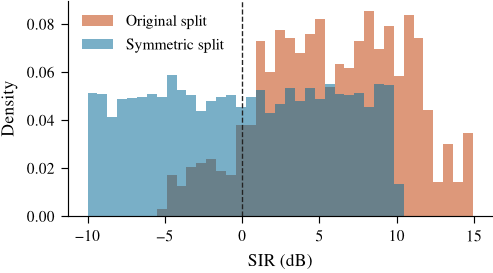

original   n=988  median +6.01 dB  target louder in 90.0% of trials
symmetric  n=4930  median +0.11 dB  target louder in 50.4% of trials


In [7]:
def sir_values(split):
    p = REPO / f"data/manifests/{split}.csv"
    if not p.exists():
        print(f"skip {split}: no manifest"); return None
    return [float(r["sir_db"]) for r in csv.DictReader(open(p)) if r["sir_db"] not in ("", None)]

before = sir_values("mid_train")      # the pre-sir0 split
after   = sir_values("sir0_train")

if before and after:
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN * 0.62, 2.0))
    bins = np.linspace(min(before + after), max(before + after), 40)
    ax.hist(before, bins=bins, color=ACCENT2, alpha=0.55, edgecolor="none",
            label="Original split", density=True)
    ax.hist(after,  bins=bins, color=ACCENT,  alpha=0.55, edgecolor="none",
            label="Symmetric split", density=True)
    ax.axvline(0, color=INK, lw=0.7, ls="--")
    ax.set_xlabel("SIR (dB)"); ax.set_ylabel("Density")
    ax.legend(frameon=False)
    save(fig, "sir_centring"); plt.show()
    for nm, v in [("original", before), ("symmetric", after)]:
        v = np.array(v)
        print(f"{nm:10s} n={len(v)}  median {np.median(v):+.2f} dB  "
              f"target louder in {100*(v>0).mean():.1f}% of trials")